# DNN for Battery Time to Depletion Prediction (Improved)
This notebook demonstrates how to build a DNN model to predict the time to depletion for

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [48]:
df_original = pd.read_csv('/Final_codes/DATASET.csv')
df = df_original.copy() # Work on a copy to keep original intact
print("Dataset loaded successfully. Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

Dataset loaded successfully. Shape: (5437, 10)

First 5 rows of the dataset:
   Current  Voltage    Ah Out  Cumulative Actual Disch Ah     Power  \
0     9.36    11.84  0.156000                    0.156000  110.8224   
1     9.34    11.84  0.155667                    0.311667  110.5856   
2     9.34    11.83  0.155667                    0.467333  110.4922   
3     7.14    11.88  0.119000                    0.586333   84.8232   
4     7.13    11.88  0.118833                    0.705167   84.7044   

   Remaining Capacity  Time to Depletion type  capacity  charged  
0           26.844000       10324.615385   b2     88.81     27.0  
1           26.688333       10286.723769   b2     88.81     27.0  
2           26.532667       10226.723769   b2     88.81     27.0  
3           26.413667       13317.815126   b2     88.81     27.0  
4           26.294833       13276.493689   b2     88.81     27.0  


In [49]:
TARGET_COL = 'Time to Depletion'

categorical_features = ['type']
numerical_features = [
    'Current', 'Voltage', 'Ah Out', 'Cumulative Actual Disch Ah',
    'Power', 'Remaining Capacity', 'capacity', 'charged'
]

all_expected_cols = numerical_features + categorical_features + [TARGET_COL]
missing_cols = [col for col in all_expected_cols if col not in df.columns]

X = df[numerical_features + categorical_features]
y = df[TARGET_COL]
print("\nFeatures (X) and Target (y) defined successfully.")
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) and Target (y) defined successfully.
Features (X) shape: (5437, 9)
Target (y) shape: (5437,)


In [50]:

numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Scale numerical features
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # One-hot encode categorical features
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough'
)
print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

num_feature_names = numerical_features
cat_feature_names_out = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
processed_feature_names = num_feature_names + list(cat_feature_names_out)
print(f"\nProcessed feature names (first 10): {processed_feature_names[:10]}")
print(f"Total processed features: {len(processed_feature_names)}")

print("\nX_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("\nSample of processed training data (first 3 rows, all columns):")
print(X_train_processed[:3])

if np.isnan(X_train_processed).any() or np.isnan(X_test_processed).any():
     print("\nWarning: NaNs found in processed data. Check initial data cleaning and preprocessing steps.")


Training set size: 4349 samples
Test set size: 1088 samples

Processed feature names (first 10): ['Current', 'Voltage', 'Ah Out', 'Cumulative Actual Disch Ah', 'Power', 'Remaining Capacity', 'capacity', 'charged', 'type_b1', 'type_b2']
Total processed features: 13

X_train_processed shape: (4349, 13)
X_test_processed shape: (1088, 13)

Sample of processed training data (first 3 rows, all columns):
[[-0.99893497  1.22116258 -0.99893497 -1.41212494 -0.911913    1.87707762
  -0.14367208  0.63039601  0.          0.          0.          1.
   0.        ]
 [ 1.22111827  0.06731541  1.22111827  0.53457233  1.19033224 -0.11647403
  -0.14367208  0.63039601  0.          0.          0.          1.
   0.        ]
 [ 1.23305404  0.47858767  1.23305404 -0.11918612  1.29535781  0.5530195
  -0.14367208  0.63039601  0.          0.          0.          1.
   0.        ]]


In [52]:
input_dim = X_train_processed.shape[1]
print(f"\nInput dimension for DNN: {input_dim}")

model = Sequential([
    Input(shape=(input_dim,), name='Input_Layer'),
    Dense(128, activation='relu', name='Hidden_Layer_1'),
    Dropout(0.2), # Adding Dropout for regularization
    Dense(64, activation='relu', name='Hidden_Layer_2'),
    Dropout(0.2),
    Dense(32, activation='relu', name='Hidden_Layer_3'),
    Dropout(0.2),
    Dense(16, activation='relu', name='Hidden_Layer_4'),
    Dropout(0.2),
    Dense(8, activation='relu', name='Hidden_Layer_5'),
    Dropout(0.2),
    Dense(4, activation='relu', name='Hidden_Layer_6'),
    Dropout(0.2),
    Dense(2, activation='relu', name='Hidden_Layer_7'),
    Dense(1, activation='linear', name='Output_Layer') # Linear activation for regression target
], name="Battery_DNN_Model")

print("\nDNN Model Summary:")
model.summary()


Input dimension for DNN: 13

DNN Model Summary:


Model: "Battery_DNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_5 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_6 (Dense)          │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_7 (Dense)          │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,841 (50.16 KB)

 Trainable params: 12,841 (50.16 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse', metrics=['mae'])

In [54]:
print("\nTraining the DNN model...")

y_train_np = np.asarray(y_train).astype('float32')
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=15, # Increased patience slightly
    restore_best_weights=True,
    verbose=2
)

history = model.fit(
    X_train_processed, y_train_np,
    epochs=150, # Increased epochs, early stopping will manage
    batch_size=32,
    validation_split=0.2, # 20% of training data for validation
    verbose=2,
    callbacks=[early_stopping_callback]
)
print("Model training complete.")


Training the DNN model...
Epoch 1/150
109/109 - 1s - 7ms/step - loss: 3351713280.0000 - mae: 16051.1270 - val_loss: 788134528.0000 - val_mae: 15648.6191
Epoch 2/150
109/109 - 0s - 831us/step - loss: 3098628864.0000 - mae: 11637.2100 - val_loss: 306601152.0000 - val_mae: 6117.5234
Epoch 3/150
109/109 - 0s - 772us/step - loss: 2927490048.0000 - mae: 9861.8496 - val_loss: 233385104.0000 - val_mae: 6422.1470
Epoch 4/150
109/109 - 0s - 805us/step - loss: 2829398528.0000 - mae: 9700.9873 - val_loss: 213979552.0000 - val_mae: 6203.3081
Epoch 5/150
109/109 - 0s - 803us/step - loss: 2744326144.0000 - mae: 9623.7998 - val_loss: 199061216.0000 - val_mae: 6100.3071
Epoch 6/150
109/109 - 0s - 801us/step - loss: 2885950976.0000 - mae: 9044.3799 - val_loss: 198000528.0000 - val_mae: 5846.5464
Epoch 7/150
109/109 - 0s - 815us/step - loss: 2738820608.0000 - mae: 9001.3672 - val_loss: 171171760.0000 - val_mae: 6073.3765
Epoch 8/150
109/109 - 0s - 808us/step - loss: 2589518336.0000 - mae: 9595.5986 - va

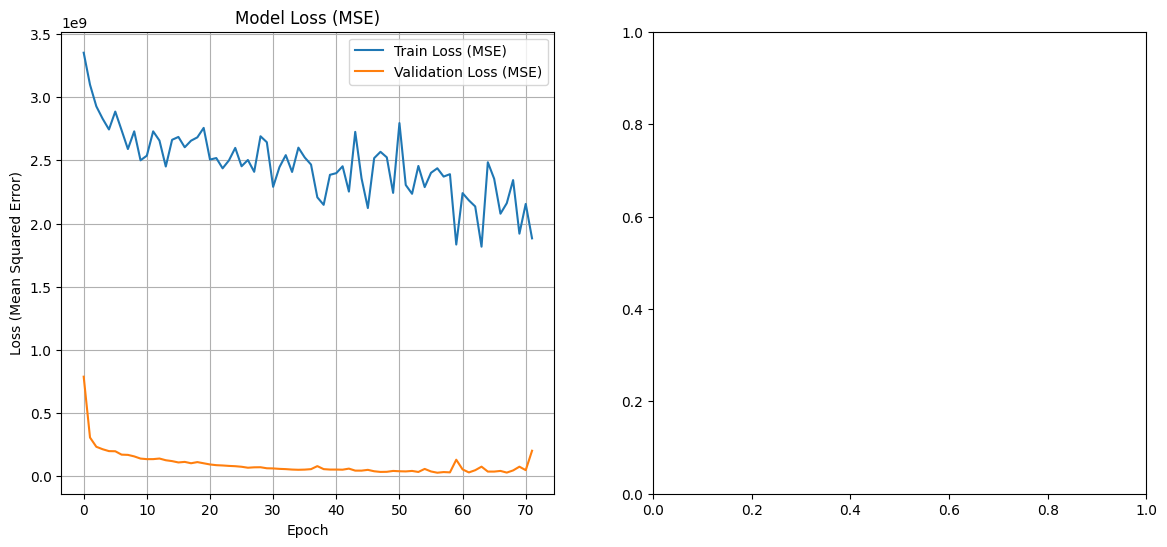

In [55]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
if 'loss' in history.history and 'val_loss' in history.history:
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.title('Model Loss (MSE)')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True)

plt.subplot(1, 2, 2)
if 'mean_absolute_error' in history.history and 'val_mean_absolute_error' in history.history:
    plt.plot(history.history['mean_absolute_error'], label='Train MAE')
    plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
    plt.title('Model Mean Absolute Error')
    plt.ylabel('Mean Absolute Error')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True)

In [56]:
print("\nEvaluating model on the test set...")
y_test_np = np.asarray(y_test).astype('float32')
test_loss, test_mae = model.evaluate(X_test_processed, y_test_np, verbose=0)
print(f"Test Mean Squared Error (MSE): {test_loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {test_mae:.4f}")


Evaluating model on the test set...
Test Mean Squared Error (MSE): 22873648.0000
Test Mean Absolute Error (MAE): 3192.9814


In [57]:
predictions = model.predict(X_test_processed).flatten()
y_test_values = y_test.reset_index(drop=True)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step
